# 📘 Домашнє завдання №18. Задача кластеризації: метрики відстані, метод k-means

Виконав: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/DataScience-PBY_HW18


Для виконання роботи використайте датасет Kaggle:
https://www.kaggle.com/datasets/saquib7hussain/k-mean-cluster-dataset



# Завдання

## 1. Завантаження та аналіз датасету

### Необхідно:
1. Завантажити датасет із Kaggle.
2. Імпортувати дані у Google Colab.
3. Вивести:
   - перші рядки таблиці;
   - інформацію про датасет;
   - статистичний опис даних.

### Використати:
```python
df.head()
df.info()
df.describe()
```

---

# 2. Підготовка даних

## Масштабування даних

Виконати нормалізацію ознак за допомогою:
- StandardScaler.

### Використати:
```python
from sklearn.preprocessing import StandardScaler
```

### Завдання:
1. Вибрати числові ознаки.
2. Масштабувати дані.

---

# 3. Метод ліктя

## Побудова Elbow Method

### Необхідно:
1. Запустити k-means для:
   - k від 1 до 10.
2. Обчислити:
   - WCSS (inertia).
3. Побудувати графік методу ліктя.

### Візуалізувати:
- залежність WCSS від кількості кластерів.

### Пояснити:
- де знаходиться «лікоть»;
- яке значення k є оптимальним візуально.

---

# 4. Автоматичне знаходження «коліна» через Kneedle Algorithm

## Необхідно:
1. Встановити бібліотеку:
```python
!pip install kneed
```

2. Використати:
```python
from kneed import KneeLocator
```

3. Автоматично знайти:
- elbow point.

---

## Завдання

### Побудувати:
- графік WCSS;
- вертикальну лінію для знайденого optimal k.

### Пояснити:
- як працює Kneedle Algorithm;
- чому:
```python
curve='convex'
direction='decreasing'
```

---

# 5. Silhouette Score

## Необхідно:
1. Обчислити silhouette score для:
- k від 2 до 10.

2. Побудувати графік:
- залежності Silhouette Score від k.

3. Автоматично знайти:
- k з максимальним silhouette score.

---

## Пояснити:
- що означає silhouette score;
- яке значення є хорошим;
- чи збігається optimal k з методом ліктя.

---

# 6. Побудова фінальної моделі

## Необхідно:
1. Побудувати фінальну модель k-means:
```python
KMeans(n_clusters=best_k)
```

2. Отримати:
- labels;
- centroids.

---

# 7. Візуалізація кластерів

## Побудувати:
- scatter plot кластерів;
- центроїди кластерів.

### На графіку:
- різні кольори для кластерів;
- центроїди позначити окремо.


In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "kagglehub[pandas-datasets]",
#     "numpy",
#     "matplotlib",
#     "scipy",
#     "statsmodels",
#     "joblib",
#     "seaborn",
#     "mpl_toolkits",
#     "sklearn",
#     "kneed",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# # Synchronization with remote source
#
# import shutil
# from pathlib import Path
#
# # Input data
hm_version = 18
#
# # Solution
# git_project_url = f"https://github.com/BogdanPinchuk/DataScience-PBY_HW{hm_version}.git"
# main_file_name = f"Bohdan_Pinchuk_DS_HW{hm_version}.ipynb"
#
# # upload all files
# current_path = !pwd
# current_path = current_path[0]
# parent_path = !dirname "$current_path"
# parent_path = parent_path[0]
# temp_path = f"{parent_path}/temp"
#
# # Clone data
# !rm -rf "$temp_path"
# !git clone "$git_project_url" "$temp_path"
#
# source = Path(temp_path)
# destination = Path(current_path)
# exclude = {main_file_name, ".git", ".idea"}
#
# for item in source.iterdir():
#     if item.name in exclude:
#         continue
#
#     target = destination / item.name
#     if item.is_dir():
#         shutil.copytree(item, target, dirs_exist_ok=True)
#     else:
#         shutil.copy2(item, target)
#
# # Clean temp folder
# !rm -rf "$temp_path"

## ✳️ Підготовка датасетів

In [3]:
# Downloading data

import pandas as pd
import apps.main as mn

# Input data
update_db = False
db_file_name = f"resources/store_hw{hm_version}.db"

# Solution
pd.options.display.float_format = "{:g}".format
k_means_cluster_dataset = mn.download_and_extract_from_kagglehub("saquib7hussain/k-mean-cluster-dataset",
                                                                 "cluster_data.csv",
                                                                 db_file_name, update_db)

# Print result
# display(k_means_cluster_dataset)


## ✅ Рішення 1

Необхідно:
1. Завантажити датасет із Kaggle.
2. Імпортувати дані у Google Colab.
3. Вивести:
   - перші рядки таблиці;
   - інформацію про датасет;
   - статистичний опис даних.

Використати:
```python
df.head()
df.info()
df.describe()
```

In [4]:
# Data description

import numpy as np
import pandas as pd
import apps.reporter as rpt
from IPython.display import display
from IPython.core.display import Markdown

# Input data
ds_name = "K-mean Cluster"
n_first_rows = 5

# Solution
data_set = k_means_cluster_dataset

n_columns = data_set.columns.size
n_rows = data_set.index.size

types_df = pd.DataFrame(data_set.dtypes, columns=["Types"])

col_num_type = data_set.select_dtypes(include=np.number)
col_cat_type = data_set.select_dtypes(exclude=np.number)

empty_val_by_col = data_set.isnull().sum().to_frame(name='count')
is_empty_val = empty_val_by_col.values.sum() > 0

rp = rpt.Reporter()
rp.add_item("Кількість рядків", str(n_rows))
rp.add_item("Кількість стовпців", str(n_columns))
rp.add_item("Кількість числових ознак", str(col_num_type.size))
rp.add_item("Кількість категоріальних ознак", str(col_cat_type.size))
rp.add_item("Пропущені значення", 'є' if is_empty_val > 0 else 'немає')

# Print results
display(Markdown(f"### Аналіз даних"))
display(data_set.head(n_first_rows).style.set_caption(f"Перші {n_first_rows} рядків датасету"))

rp.print_pd_report("Параметри таблиці")

if is_empty_val > 0:
    display(empty_val_by_col.style.set_caption("Кількість пропусків"))
display(types_df.style.set_caption("Типи даних"))

display(data_set.describe().T.style.format("{:g}").set_caption("Статистика числових змінних"))

data_set.info()


### Аналіз даних

,Feature 1,Feature 2
0,2.698582,-0.672960
1,-0.128113,4.355952
2,2.509049,5.773146
3,-1.518276,3.444886
4,-0.072283,2.883769


Attribute,Result
Кількість рядків,500
Кількість стовпців,2
Кількість числових ознак,1000
Кількість категоріальних ознак,0
Пропущені значення,немає


,Types
Feature 1,float64
Feature 2,float64


,count,mean,std,min,25%,50%,75%,max
Feature 1,500,1.83135,4.08615,-3.89649,-1.17403,0.604212,2.75021,11.8677
Feature 2,500,2.69497,3.49417,-4.37849,0.200712,2.80775,5.13251,10.2162


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature 1  500 non-null    float64
 1   Feature 2  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


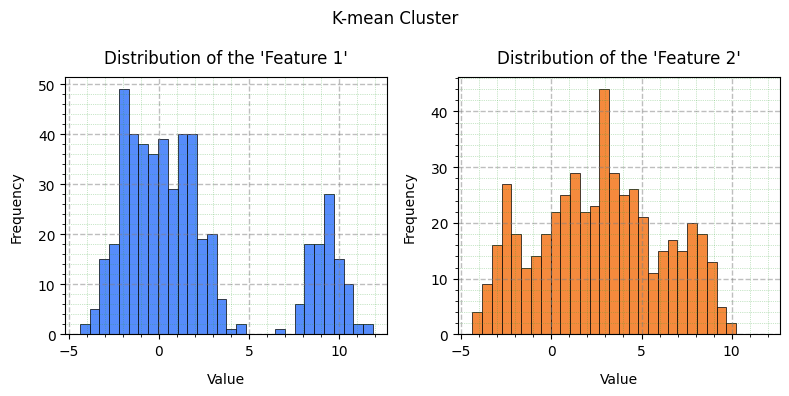

In [5]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
n_bins = 30
n_columns = 2
data_set = k_means_cluster_dataset

# Solution
axes = data_set.plot.hist(subplots=True, layout=(-1, n_columns), figsize=(8, 4),
                          bins=n_bins, edgecolor="black", linewidth=0.5, sharex=False, sharey=False)

for i, ax_l in enumerate(axes.flatten()):
    legend_text = ax_l.get_legend().get_texts()[0].get_text()

    ax_l.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    ax_l.minorticks_on()
    ax_l.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax_l.set_title(f"Distribution of the '{legend_text}'", pad=10, loc='center', color='black')
    ax_l.set_xlabel("Value", labelpad=10, loc='center', color='black')
    ax_l.set_ylabel("Frequency", labelpad=10, loc='center', color='black')
    ax_l.get_legend().set_visible(False)

plt.suptitle(ds_name)

plt.tight_layout()
plt.show()

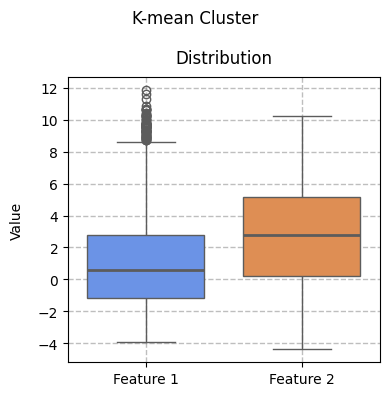

In [6]:
# Graphic results

import seaborn as sns
import matplotlib.pyplot as plt

# Input data
data_set = k_means_cluster_dataset

# Solution
_, ax_l = plt.subplots(figsize=(4, 4))

sns.boxplot(data_set, ax=ax_l, width=0.75, medianprops={'linewidth': 2.0})

ax_l.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax_l.set_title("Distribution", pad=10, loc='center', color='black')
ax_l.set_ylabel("Value", labelpad=10, loc='center', color='black')

plt.suptitle(ds_name)

plt.tight_layout()
plt.show()

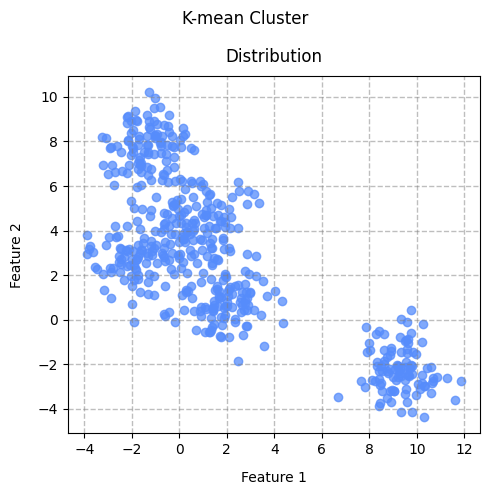

In [7]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = k_means_cluster_dataset

# Solution
_, axes = plt.subplots(figsize=(5, 5))

ax_l = axes
ax_l.scatter(x=data_set.iloc[:, 0], y=data_set.iloc[:, 1], alpha=0.75)

ax_l.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax_l.set_title("Distribution", pad=10, loc='center', color='black')
ax_l.set_xlabel(data_set.columns[0], labelpad=10, loc='center', color='black')
ax_l.set_ylabel(data_set.columns[1], labelpad=10, loc='center', color='black')

plt.suptitle(ds_name)

plt.tight_layout()
plt.show()

In [8]:
# Additionally

# Input data
n_bins_1 = 40
n_bins_2 = 40
data_set = k_means_cluster_dataset

# Solution
data_f1 = data_set.iloc[:, 0]
data_f2 = data_set.iloc[:, 1]

bins_f1 = np.linspace(data_f1.min(), data_f1.max(), n_bins_1 + 1).round(2)
bins_f2 = np.linspace(data_f2.min(), data_f2.max(), n_bins_1 + 1).round(2)

f1_cut = pd.cut(data_f1, bins=bins_f1, include_lowest=True)
f2_cut = pd.cut(data_f2, bins=bins_f2, include_lowest=True)

f_matrix = pd.crosstab(f2_cut, f1_cut, dropna=False).sort_index(ascending=False)
# f_matrix = pd.crosstab(f1_cut, f2_cut, dropna=False)

# Print results
# display(f_matrix.style.set_caption("Дискретизація точок"))

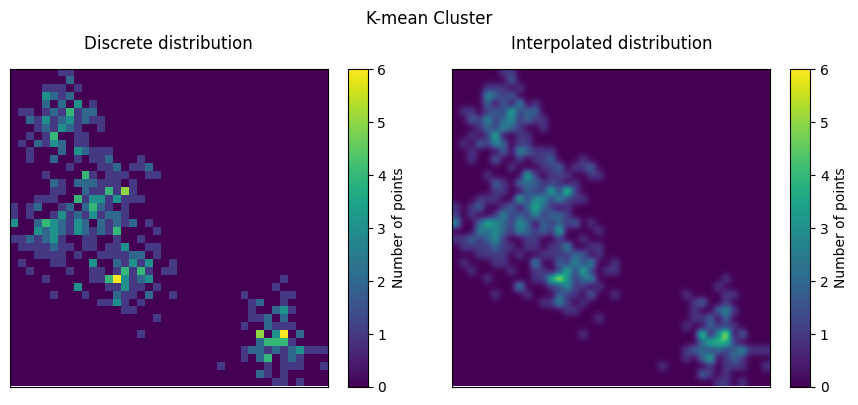

In [9]:
# Graphic results - Scatter Plot - Matplotlib

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Input data

# Solution
_, axes = plt.subplots(1, 2, figsize=(9, 4))

ax_l = axes[0]
ax_l.imshow(f_matrix)
# ax.contour(f_matrix, levels=2, colors='white', linewidths=1.5)

ax_l.set_yticks([])
ax_l.set_xticks([])
# ax.set_yticks(range(len(f_matrix)), labels=f_matrix.index)
# ax.set_xticks(range(len(f_matrix)), labels=f_matrix.columns)
# plt.setp(ax.get_xticklabels(), rotation=90)

divider = make_axes_locatable(ax_l)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(f_matrix.values.min(), f_matrix.values.max())
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax_l.figure.colorbar(sm, cax=cb_ax, label='Number of points')
ax_l.set_title("Discrete distribution", pad=15, loc='center', color='black')

ax_l = axes[1]
ax_l.imshow(f_matrix, interpolation='gaussian')
# ax.contour(f_matrix, levels=2, colors='white', linewidths=1.5)

ax_l.set_yticks([])
ax_l.set_xticks([])
# ax.set_yticks(range(len(f_matrix)), labels=f_matrix.index)
# ax.set_xticks(range(len(f_matrix)), labels=f_matrix.columns)
# plt.setp(ax.get_xticklabels(), rotation=90)

divider = make_axes_locatable(ax_l)
cb_ax = divider.append_axes("right", size=0.2, pad=0.2)

norm = plt.Normalize(f_matrix.values.min(), f_matrix.values.max())
sm = plt.cm.ScalarMappable(norm=norm)
sm.set_array([])
ax_l.figure.colorbar(sm, cax=cb_ax, label='Number of points')
ax_l.set_title("Interpolated distribution", pad=15, loc='center', color='black')

plt.suptitle(ds_name)

plt.tight_layout()
plt.show()

## ✅ Рішення 2

Масштабування даних

Виконати нормалізацію ознак за допомогою:
- StandardScaler.

Використати:
```python
from sklearn.preprocessing import StandardScaler
```

Завдання:
1. Вибрати числові ознаки.
2. Масштабувати дані.

In [10]:
# Scaling

from sklearn.preprocessing import StandardScaler

# Input data
k_means_cluster_dataset_sc = k_means_cluster_dataset.copy()
data_set = k_means_cluster_dataset_sc

# Solution
scaler = StandardScaler()

for col_name in col_num_type.columns:
    col_data = data_set[col_name].values.reshape(-1, 1)
    scaled_data = scaler.fit_transform(col_data)
    data_set[col_name] = scaled_data

# Print results
display(data_set.describe().T.style.format("{:g}").set_caption("Статистика масштабованих числових змінних"))


,count,mean,std,min,25%,50%,75%,max
Feature 1,500,4.52971e-17,1.001,-1.40317,-0.736242,-0.300618,0.225097,2.45864
Feature 2,500,-7.54952e-17,1.001,-2.02639,-0.71455,0.0323078,0.6983,2.15467


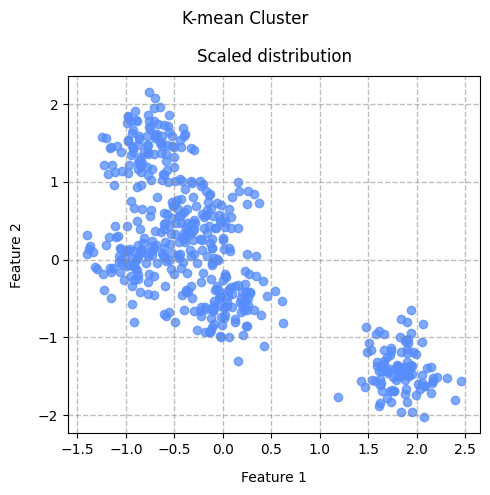

In [11]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
data_set = k_means_cluster_dataset_sc

# Solution
_, axes = plt.subplots(figsize=(5, 5))

ax_l = axes
ax_l.scatter(x=data_set.iloc[:, 0], y=data_set.iloc[:, 1], alpha=0.75)

ax_l.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax_l.set_title("Scaled distribution", pad=10, loc='center', color='black')
ax_l.set_xlabel(data_set.columns[0], labelpad=10, loc='center', color='black')
ax_l.set_ylabel(data_set.columns[1], labelpad=10, loc='center', color='black')

plt.suptitle(ds_name)

plt.tight_layout()
plt.show()

## ✅ Рішення 3

Необхідно:
1. Запустити k-means для:
   - k від 1 до 10.
2. Обчислити:
   - WCSS (inertia).
3. Побудувати графік методу ліктя.

Візуалізувати:
- залежність WCSS від кількості кластерів.

Пояснити:
- де знаходиться «лікоть»;
- яке значення k є оптимальним візуально.

In [12]:
# K-means

from sklearn.cluster import KMeans
from joblib import Parallel, delayed

# Input data
rng_seed = 42
n_max_clusters = 10
data_set = k_means_cluster_dataset_sc


# Solution
def calc_k_means(k: int, data_set: pd.DataFrame, rng_seed: int) -> tuple[int, float]:
    """
    Calculation K-means
    :param k: n clusters
    :param data_set: input dataset
    :param rng_seed: random seed
    :return: list of tuples (k, inertia)
    """
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=rng_seed,
        n_init=10,
    )
    kmeans.fit(data_set.values)
    return k, kmeans.inertia_


k_means_list = Parallel(n_jobs=-1)(
    delayed(calc_k_means)(k, data_set, rng_seed)
    for k in range(1, n_max_clusters + 1)
)

wcss = dict(k_means_list)

x_data = np.asarray(list(wcss.keys()))
y_data = np.asarray(list(wcss.values()))

norm_coef_curv = mn.calc_curvature_coef(x_data, y_data, normalize=True)
idx = np.argmax(np.abs(norm_coef_curv))
best_k = x_data[idx]

rp = rpt.Reporter()
rp.add_item("Оптимальне k", str(best_k))

# Print results
rp.print_pd_report("Метод ліктя")


Attribute,Result
Оптимальне k,3


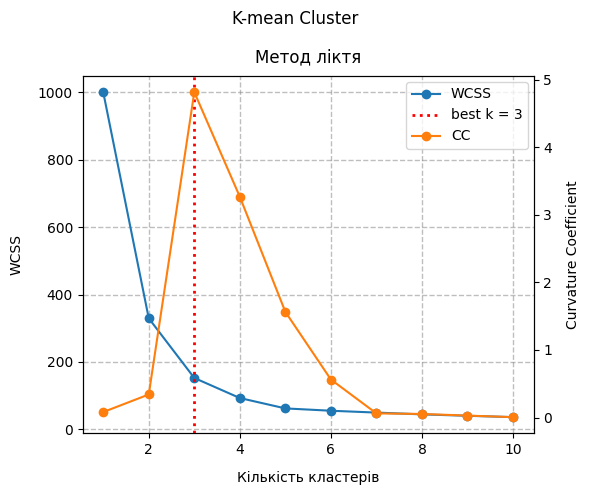

In [13]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
fig, axes = plt.subplots(figsize=(6, 5))

ax_l = axes
ax_l.plot(wcss.keys(), wcss.values(), marker='o', label='WCSS', color='tab:blue')
ax_l.axvline(best_k, linestyle=':', color='red', linewidth=2.0, label=f"best k = {best_k}")

ax_l.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax_l.set_title("Метод ліктя", pad=10, loc='center', color='black')
ax_l.set_xlabel("Кількість кластерів", labelpad=10, loc='center', color='black')
ax_l.set_ylabel("WCSS", labelpad=10, loc='center', color='black')

ax_r = ax_l.twinx()
ax_r.plot(wcss.keys(), norm_coef_curv, marker='o', label='CC', color='tab:orange')
ax_r.set_ylabel("Curvature Coefficient", labelpad=10, loc='center', color='black')

plt.suptitle(ds_name)

fig.legend(bbox_to_anchor=(0.9, 0.85))
plt.tight_layout()
plt.show()

Кривина кривої [https://uk.wikipedia.org/wiki/Кривина_(математика)]:
$$k = \frac{{d}x \cdot {d}^2y - {d}y \cdot {d}^2x}{\left(({dx})^2 + ({dy})^2\right)^{3/2}}$$
Радіус кривини:
$$r = \frac{1}{|k|}$$
- При $k > 0$ — ввігнута крива;
- При $k < 0$ — опукла крива;


Висновок. "Лікоть" знаходиться в точці "вигину", де графік із крутого падіння переходить у плавне. Візуально це визначається як точка, в якій крива графіка має найбільшу кривизну (найменший радіус кривини). Коефіцієнт кривини — це значення, яке обернено пропорційне радіусу кривини, а відповідно, найбільший коефіцієнт указуватиме на найменший радіус. Оскільки принцип "ліктя" проводиться візуально при масштабованих осях, а не реальному масштабі значень, перед знаходженням квизизни графіка (а не даних) нам потрібно привести осі до одного масштабу. У результаті ми можемо знайти, якій точці відповідає найбільший коефіцієнт кривини, і ця точка й буде оптимальним значенням для кількості кластерів. При цьому потрібно аналізувати максимальне значення модулів кривин. У нашому випадку ми отримали 3. Результати візуального аналізу сходяться з автоматизованим розрахунком.

## ✅ Рішення 4

Необхідно:
1. Встановити бібліотеку:
```python
!pip install kneed
```

2. Використати:
```python
from kneed import KneeLocator
```

3. Автоматично знайти:
- elbow point.

---

Завдання

Побудувати:
- графік WCSS;
- вертикальну лінію для знайденого optimal k.

Пояснити:
- як працює Kneedle Algorithm;
- чому:
```python
curve='convex'
direction='decreasing'
```

In [14]:
# Kneed

from kneed import KneeLocator

# Input data

# Solution
kneedle = KneeLocator(
    list(wcss.keys()),
    list(wcss.values()),
    curve='convex',
    direction='decreasing'
)

best_k_kneedle = kneedle.elbow

rp = rpt.Reporter()
rp.add_item("Оптимальне k", str(best_k_kneedle))

# Print results
rp.print_pd_report("Kneedle алгоритм")

Attribute,Result
Оптимальне k,3


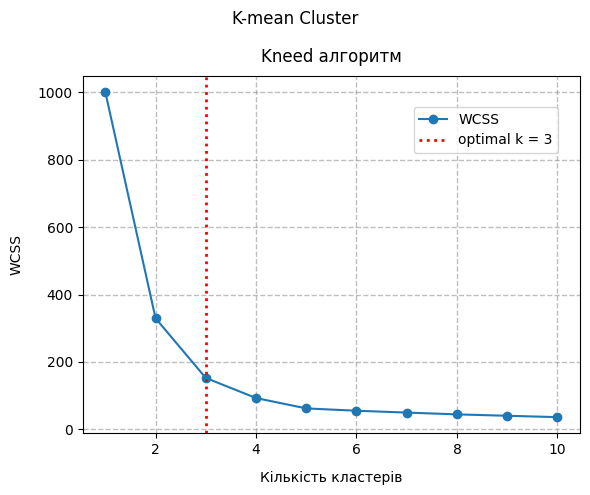

In [30]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
fig, axes = plt.subplots(figsize=(6, 5))

ax = axes
ax.plot(wcss.keys(), wcss.values(), marker='o', label='WCSS', color='tab:blue')
ax.axvline(best_k_kneedle, linestyle=':', color='red', linewidth=2.0, label=f"optimal k = {best_k_kneedle}")

ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Kneed алгоритм", pad=10, loc='center', color='black')
ax.set_xlabel("Кількість кластерів", labelpad=10, loc='center', color='black')
ax.set_ylabel("WCSS", labelpad=10, loc='center', color='black')

plt.suptitle(ds_name)

fig.legend(bbox_to_anchor=(0.95, 0.8))
plt.tight_layout()
plt.show()

Висновок. Kneed алгоритм доволі чутливий до вказаних параметрів, curve='convex' — опукла вниз, схожа на чашу ('concave' — увігнута вгору, схожа на купол), direction='decreasing' — спадна траєкторія, а 'increasing' — зростаюча траєкторія. Алгоритм масштабує осі та визначає лінію, яка сполучає дві крайні точки, далі з усіх проміжних точок проводить перпендикуляри до лінії, і визначає дожини цих перпендикулярів, і найбільша довжина перпендикуляра й приймається за оптимальну точку. Обидва алгоритми (за кривиною і kneed) визначення оптимальних точок надали подібні значення.

## ✅ Рішення 5

1. Обчислити silhouette score для:
- k від 2 до 10.

2. Побудувати графік:
- залежності Silhouette Score від k.

3. Автоматично знайти:
- k з максимальним silhouette score.

Пояснити:
- що означає silhouette score;
- яке значення є хорошим;
- чи збігається optimal k з методом ліктя.

In [26]:
# Silhouette Score

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Input data
rng_seed = 42
n_max_clusters = 10
data_set = k_means_cluster_dataset_sc


# Solution
def calc_k_silhouette(k: int, data_set: pd.DataFrame, rng_seed: int) -> tuple[int, float]:
    """
    Calculation by Silhouette Score
    :param k: n clusters
    :param data_set: input dataset
    :param rng_seed: random seed
    :return: list of tuples (k, inertia)
    """
    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        random_state=rng_seed,
        n_init=10,
    )
    labels = kmeans.fit_predict(data_set.values)
    score = silhouette_score(data_set.values, labels)
    return k, score


k_silhouettes_list = Parallel(n_jobs=-1)(
    delayed(calc_k_silhouette)(k, data_set, rng_seed)
    for k in range(2, n_max_clusters + 1)
)

silhouette_scores = dict(k_silhouettes_list)

x_data = np.asarray(list(silhouette_scores.keys()))
y_data = np.asarray(list(silhouette_scores.values()))

idx = np.argmax(y_data)
best_k_silhouette = x_data[idx]

rp = rpt.Reporter()
rp.add_item("Оптимальне k", str(best_k_silhouette))

# Print results
rp.print_pd_report("Silhouette Score підхід")

Attribute,Result
Оптимальне k,2


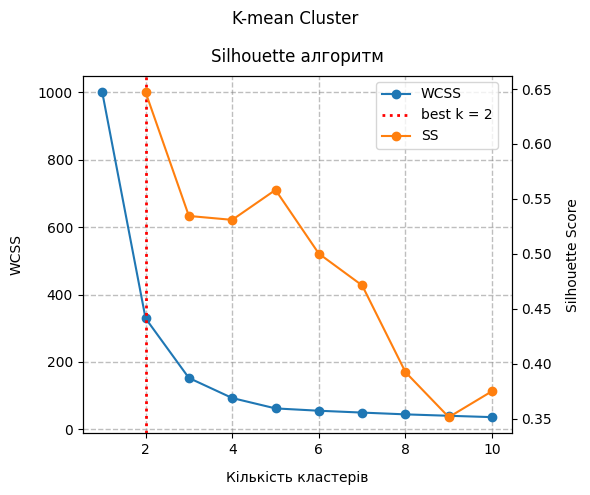

In [33]:
# Graphic results

import matplotlib.pyplot as plt

# Input data

# Solution
fig, axes = plt.subplots(figsize=(6, 5))

ax_l = axes
ax_l.plot(wcss.keys(), wcss.values(), marker='o', label='WCSS', color='tab:blue')
ax_l.axvline(best_k_silhouette, linestyle=':', color='red', linewidth=2.0, label=f"best k = {best_k_silhouette}")

ax_l.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
# ax.minorticks_on()
# ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax_l.set_title("Silhouette алгоритм", pad=10, loc='center', color='black')
ax_l.set_xlabel("Кількість кластерів", labelpad=10, loc='center', color='black')
ax_l.set_ylabel("WCSS", labelpad=10, loc='center', color='black')

ax_r = ax_l.twinx()
ax_r.plot(silhouette_scores.keys(), silhouette_scores.values(), marker='o', label='SS', color='tab:orange')
ax_r.set_ylabel("Silhouette Score", labelpad=10, loc='center', color='black')

plt.suptitle(ds_name)

fig.legend(bbox_to_anchor=(0.85, 0.85))
plt.tight_layout()
plt.show()

Висновок. Silhouette Score оцінює якість кластеризації на основі того, наскільки об'єкт близький до свого кластера (компактність) порівняно з іншими сусідніми кластерами (відокремленість). Чим значення є ближчі до +1, тим краще обʼєкт уписався в кластер, якщо нуль, то обʼєкт знаходить на межі кластерів, а якщо відʼємне, то обʼєкт не у своєму кластері. У цьому випадку найкращим значенням є k = 2. Розрахунок ха цим підходом відрізняється від отриманих вище значень за методом "ліктя". Це спричинене тим, що підходи оцінюють якість кластеризації за різними математичними критеріями, перші оцінюють за компактністю/щільністю точок, а цей за відстанню між сусідніми кластерами.